In [1]:
import h5py
import halotools
import os
import copy
import warnings
import numpy as np
import math
from astropy.modeling import Fittable1DModel, Parameter,models,fitting
import pickle
import warnings
import numpy.ma as ma
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.stats import spearmanr,kendalltau,pearsonr,ks_2samp
import palettable
import deepdish as dd
import matplotlib.cm as cm

from matplotlib.collections import LineCollection
from photutils.isophote import EllipseGeometry
from photutils.aperture import EllipticalAperture,EllipticalAnnulus
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
from matplotlib import colors
from astroML.stats import binned_statistic_2d
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import LinearRegression

from astropy.utils.console import ProgressBar
from astropy.table import QTable,hstack
plt.rc('text', usetex=True)
rcParams.update({'axes.linewidth': 1.5})
rcParams.update({'xtick.direction': 'in'})
rcParams.update({'ytick.direction': 'in'})
rcParams.update({'xtick.minor.visible': 'True'})
rcParams.update({'ytick.minor.visible': 'True'})
rcParams.update({'xtick.major.pad': '7.0'})
rcParams.update({'xtick.major.size': '8.0'})
rcParams.update({'xtick.major.width': '1.5'})
rcParams.update({'xtick.minor.pad': '7.0'})
rcParams.update({'xtick.minor.size': '4.0'})
rcParams.update({'xtick.minor.width': '1.5'})
rcParams.update({'ytick.major.pad': '7.0'})
rcParams.update({'ytick.major.size': '8.0'})
rcParams.update({'ytick.major.width': '1.5'})
rcParams.update({'ytick.minor.pad': '7.0'})
rcParams.update({'ytick.minor.size': '4.0'})
rcParams.update({'ytick.minor.width': '1.5'})
rcParams.update({'axes.titlepad': '10.0'})
rcParams.update({'font.size': 35})

In [2]:
fig_dir="/Users/xushuo/work/Papers/CenvsSat/Figure/"
data_dir='/Users/xushuo/work/Submit/CenvsSat/Data/'

In [3]:
with open(data_dir+"galaxies_tng300_072_hmc_13_venn_diagram_test.txt",'rb') as f: 
    tab_venn=pickle.load(f)

In [4]:
with open(data_dir+"galaxies_tng300_072_hmc_13_mhalo_c_split_f_1.txt",'rb') as f: 
    tab_cmh1=pickle.load(f)

In [5]:
with open(data_dir+"galaxies_tng300_072_hmc_13_richness_split_test_f_1.txt",'rb') as f: 
    tab_rich1=pickle.load(f)

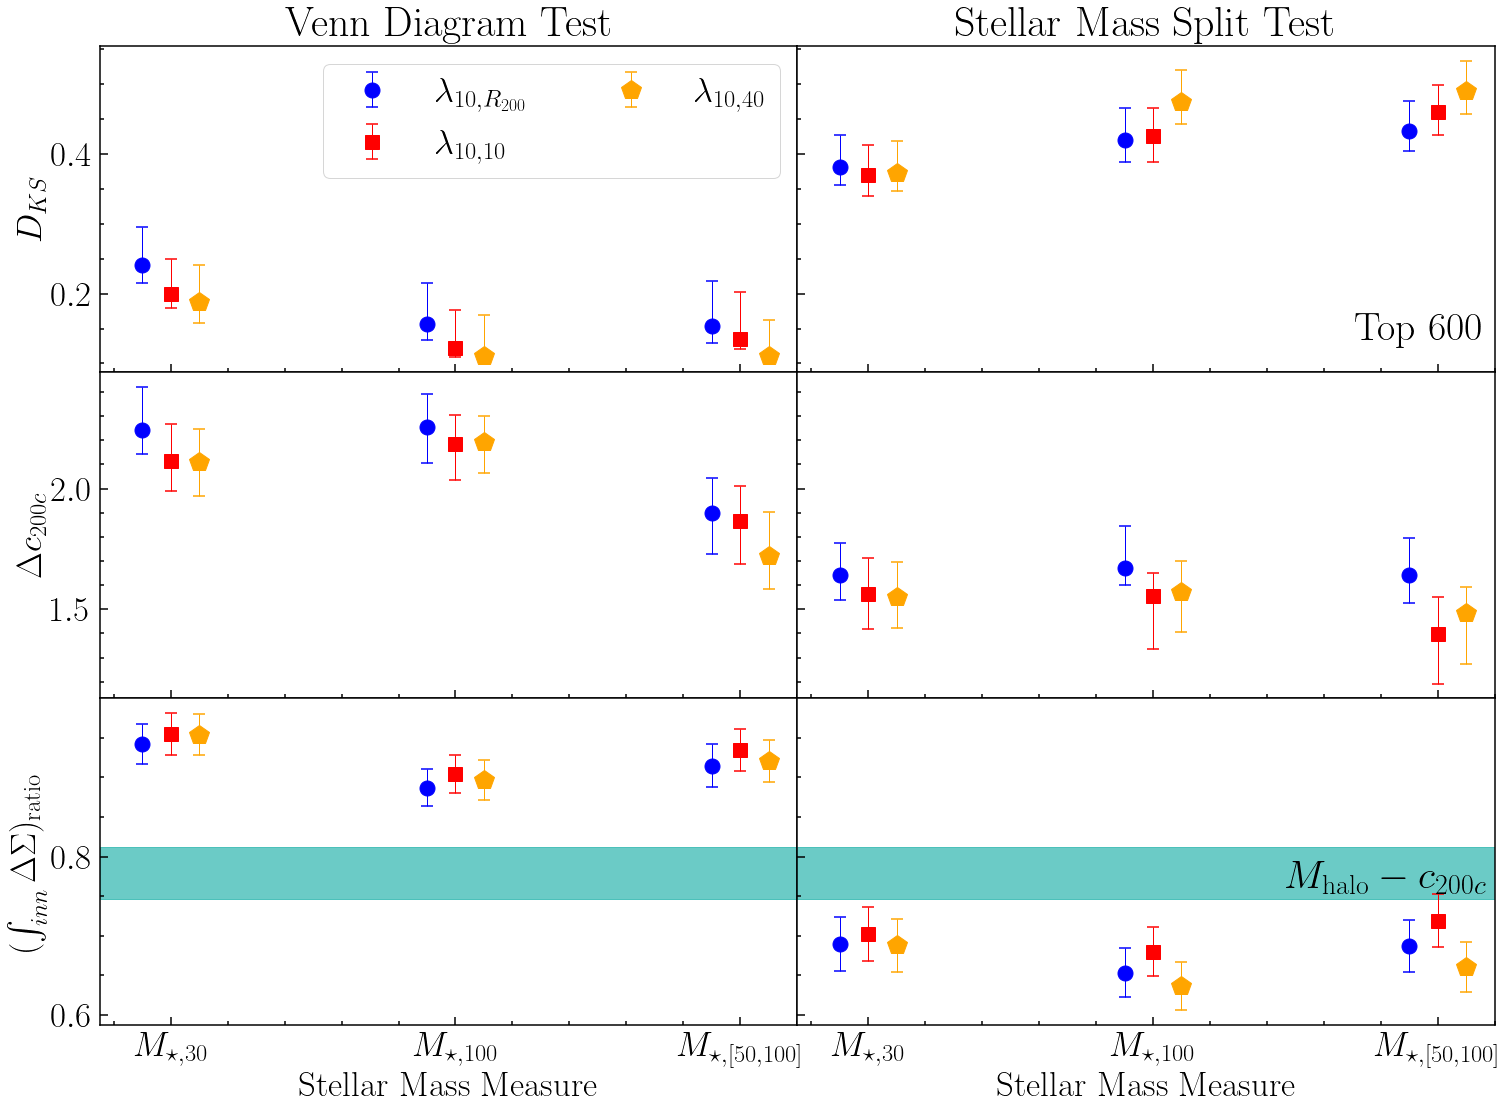

In [6]:
fig=plt.figure(figsize=(25,18))
gs = fig.add_gridspec(3,2, hspace=0, wspace=0,width_ratios=(0.3,0.3))
axlist=gs.subplots(sharey='row',sharex='col')
color_list=['blue','red','orange']
markerlist=['o','s','p','P','H','X','D','v','*','8','>']
sizelist=np.asarray([10,9,14,12,12,9,9,9,9,9,9])*1.5
name0_list=['richness_cut_r200_10','richness_cut_r200_10_xy_10','richness_cut_r200_10_xy_40']
label_list=[r'$\lambda_{10,R_{200}}$',r'$\lambda_{10,10}$',r'$\lambda_{10,40}$']
term_list=['ks_mh','dm_c','lens_ratio_inn']
ylabel_list=[r'$D_{KS}$',r'$\Delta c_{200c}$',r'$(\int_{inn}\Delta\Sigma)_{\rm ratio}$']
for ii in range(3):
    col=color_list[ii]
    mark=markerlist[ii]
    name1=name0_list[ii]
    label=label_list[ii]
    size=sizelist[ii]
    top_numb=600
    mask_v=(tab_venn['name1']==name1)&(tab_venn['top_numb']==top_numb)
    mask_s=(tab_rich1['name1']==name1)&(tab_rich1['top_numb']==top_numb)
    mask_c=(tab_cmh1['top_numb']==top_numb)
    for j in range(3):
        term=term_list[j]
        if j<2:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],
                                 yerr=(tab_venn[mask_v][term]-tab_venn[mask_v][term+'_low'],tab_venn[mask_v][term+'_upp']-tab_venn[mask_v][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],
                                 yerr=(tab_rich1[mask_s][term]-tab_rich1[mask_s][term+'_low'],tab_rich1[mask_s][term+'_upp']-tab_rich1[mask_s][term]),
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1,label=label)
            
        else:
            axlist[j,0].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_venn[mask_v][term],yerr=tab_venn[mask_v][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,1].errorbar(np.arange(0,3,1)+(0.9+0.1*ii),tab_rich1[mask_s][term],yerr=tab_rich1[mask_s][term+'_err'],
                                c=col,fmt=mark,markersize=size,capsize=6, capthick=1.5,elinewidth=1)
            axlist[j,0].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')
            axlist[j,1].axhspan(tab_cmh1[mask_c][term][0]-tab_cmh1[mask_c][term+'_err'][0],tab_cmh1[mask_c][term][0]+tab_cmh1[mask_c][term+'_err'][0],alpha=0.3,color='lightseagreen')

for j in range(3):
    axlist[j,0].set_ylabel(ylabel_list[j])
    if j>=3:
        axlist[j,0].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
        axlist[j,1].plot(np.arange(0,6,1),np.arange(0,6,1)**0,ls='--',lw=2,c='black')
axlist[-1,0].set_xticks([1,2,3],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,0].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,1].set_xticks([1,2,3],[r'$M_{\star,30}$',r'$M_{\star,100}$',r'$M_{\star,[50,100]}$'])
axlist[-1,1].set_xlabel(r'\rm Stellar Mass Measure')
axlist[-1,0].set_xlim(0.75,3.2)
axlist[-1,1].set_xlim(0.75,3.2)
axlist[0,0].legend(ncol=2)
axlist[0,0].set_title(r'\rm Venn Diagram Test')
axlist[0,1].set_title(r'\rm Stellar Mass Split Test')
ax=axlist[0,1]
ax.text(0.8,0.1,r'\rm Top %d'%top_numb,transform=ax.transAxes,fontsize=40)
ax=axlist[2,1]
ax.text(0.7,0.42,r'$M_{\rm halo}-c_{200c}$',transform=ax.transAxes,fontsize=40)
plt.savefig(fig_dir+"Fig12.pdf",dpi=150)